# Mnist Modellering
av Mattias Englund

## ML-Flöde

1. Laddning och inspektion av data
2. EDA
3. Dela Upp data i träning och test
4. Bearbetning / Preprocessing
5. Träna modeller
6. Jämför modeller
7. Utvärdering av modeller

## 1. Laddning och inspektion av data

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#Function to display ConfusionMatrix at a later stage
def display_confusion_matrix(y_true, y_pred) :
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot()

In [14]:
mnist = fetch_openml("mnist_784", version=1, cache=True, as_frame=False)

X = mnist["data"]
y = mnist["target"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Datatyp X: {X.dtype}")
print(f"Datatyp y: {y.dtype}")

# Jag kontrollerade pixelvärdenas min- och maxvärde för att säkerställa att bilderna var korrekt inlästa.
print(f"Pixelvärden min/max: {X.min():.0f} / {X.max():.0f}")

print(mnist.DESCR)

X shape: (70000, 784)
y shape: (70000,)
Datatyp X: int64
Datatyp y: object
Pixelvärden min/max: 0 / 255
**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the 

## 2. EDA

In [15]:
# Kontrollerar unika värden. 
# Då de var strängar, valde jag att konvertera från strängar till integers och sen kontrollera unika värden
y = y.astype(int)
print("Unika klasser:", np.unique(y))

Unika klasser: [0 1 2 3 4 5 6 7 8 9]


In [16]:
# Fördelning mellan klasserna
print(pd.Series(y).value_counts().sort_index())

0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64


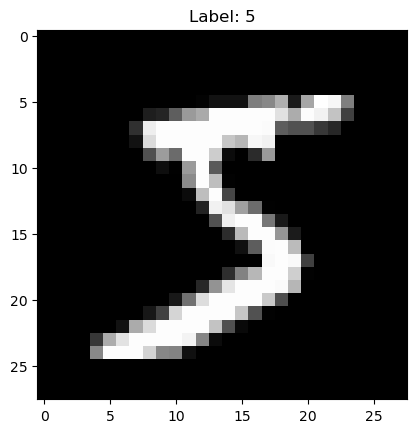

In [17]:
# Kollar en exempelbild för att se så bild och etikett stämmer överens
plt.imshow(X[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y[0]}")
plt.show()

## 3. Dela upp data i träning och test

In [ ]:
# Här delar jag upp data i träning och test. Jag använde Stratify = y vilket gör att fördelningen av siffrorna blir ungefär densamma i tränings-, validerings- och testdatan 
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=10000, random_state=42, stratify=y_train_val
)

print(f"Träningsdata: {X_train.shape[0]} bilder")
print(f"Valideringsdata: {X_val.shape[0]} bilder")
print(f"Testdata: {X_test.shape[0]} bilder")
print(f"Features per bild: {X_train.shape[1]} (= 28x28 pixlar)")

Träningsdata: 50000 bilder
Valideringsdata: 10000 bilder
Testdata: 10000 bilder
Features per bild: 784 (= 28x28 pixlar)


## 4. Bearbetning / Preprocessing

In [19]:
# Förbearbetar datan genom att standardisera tränings-, validerings- och testdatan.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## 5. Modell implementation 

### Modell 1 Logistic regression

In [20]:
# Modell 1: Logistisk Regression
# max_iter=1000 för att säkerställa konvergens, random_state=42 för reproducerbarhet
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_val_pred_lr = log_reg.predict(X_val)
acc_lr = (y_val_pred_lr == y_val).mean()
print(f"Logistic Regression - Validation accuracy: {acc_lr:.4f}")

Logistic Regression - Validation accuracy: 0.9170


### Modell 2 - KNN

In [21]:
# Modell 2: K-Nearest Neighbors
# weights='distance' ger viktat röstning baserat på avstånd, vilket förbättrar precision för MNIST
# n_jobs=-1 parallelliserar beräkningarna för snabbare körning
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
knn.fit(X_train, y_train)

y_val_pred_knn = knn.predict(X_val)
acc_knn = (y_val_pred_knn == y_val).mean()
print(f"KNN - Validation accuracy: {acc_knn:.4f}")

KNN - Validation accuracy: 0.9497


### Modell 3 - Random Forest

In [22]:
# Modell 3: Random Forest
# n_estimators=100 träd, random_state=42 för reproducerbarhet, n_jobs=-1 för parallellisering
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_val_pred_rf = rf.predict(X_val)
acc_rf = (y_val_pred_rf == y_val).mean()
print(f"Random Forest - Valideringsnoggrannhet: {acc_rf:.4f}")

Random Forest - Valideringsnoggrannhet: 0.9709


## 6. Jämför modeller

In [23]:
# Sammanfattning av valideringsnoggrannhet för alla tre modeller
results = pd.DataFrame({
    'Modell': ['Logistisk Regression', 'KNN (k=5, distance)', 'Random Forest'],
    'Valideringsnoggrannhet': [acc_lr, acc_knn, acc_rf]
})
results = results.sort_values('Valideringsnoggrannhet', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

              Modell  Valideringsnoggrannhet
       Random Forest                  0.9709
 KNN (k=5, distance)                  0.9497
Logistisk Regression                  0.9170


### Val av bästa modell

Random Forest uppnår högst valideringsnoggrannhet och väljs därför som bästa modell för slutlig utvärdering på testdata.

## 7. Utvärdering av modeller

Random Forest - Testnoggrannhet: 0.9686

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       986
           1       0.99      0.99      0.99      1125
           2       0.97      0.97      0.97       999
           3       0.96      0.95      0.96      1020
           4       0.97      0.97      0.97       975
           5       0.97      0.96      0.96       902
           6       0.97      0.99      0.98       982
           7       0.97      0.97      0.97      1042
           8       0.96      0.95      0.96       975
           9       0.94      0.95      0.94       994

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



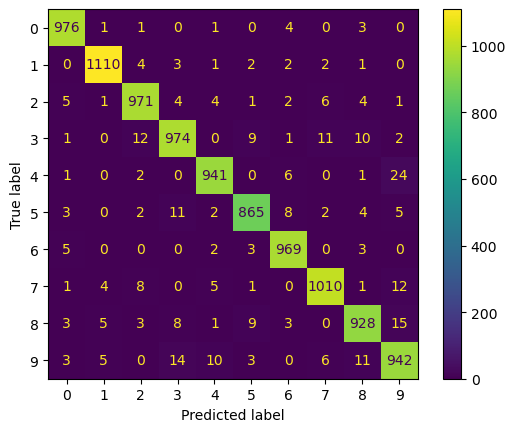

In [24]:
# Steg 7: Träna om bästa modellen (Random Forest) på hela tränings + valideringsdata och utvärdera på testdata

# Använd samma scaler som i preprocessing (fit på X_train) för att skala X_train_val
# X_test är redan skalat från preprocessing-steget
X_train_val_scaled = scaler.transform(X_train_val)

# Träna om Random Forest på hela skalade X_train_val
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train_val_scaled, y_train_val)

# Prediktera på testdata
y_test_pred = rf_final.predict(X_test)

# Testnoggrannhet
acc_test = (y_test_pred == y_test).mean()
print(f"Random Forest - Testnoggrannhet: {acc_test:.4f}")
print()

# Classification report
print(classification_report(y_test, y_test_pred))

# Konfusionsmatris
display_confusion_matrix(y_test, y_test_pred)